# **Praktikum Mandiri 7 — Prediksi (Linear Regression)**
**Dataset:** `dataset_satelit.csv`  
**Tujuan:** Membangun model Linear Regression untuk memprediksi salah satu target `N`, `P`, atau `K`.  

### **Import Library**

In [1]:
# Import library yang dibutuhkan
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import statsmodels.api as sm

# Atur tampilan pandas
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

print("Libraries imported.")

Libraries imported.


### **Load Dataset**

In [2]:
# Sinkronisasi dengan drive
from google.colab import drive
drive.mount('/content/gdrive')

# Load dataset
df = pd.read_csv('/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum07/datasets/dataset_satelit.csv', sep=',')
df.head()

Mounted at /content/gdrive


,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,Cu,Zn,B,b12,b11,b9,b8a,b8,b7,b6,b5,b4,b3,b2,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,5.60,16.69,26.58,0.1013,0.1922,0.4753,0.3354,0.2930,0.3066,0.0897,0.2467,0.0432,0.0548,0.0337,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,0.65,14.47,13.60,0.1057,0.1941,0.4811,0.3208,0.2828,0.2953,0.0939,0.2385,0.0626,0.0677,0.0445,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,2.82,14.75,29.31,0.0836,0.1750,0.4981,0.3655,0.3166,0.3346,0.0866,0.2599,0.0444,0.0622,0.0403,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,2.53,15.32,20.24,0.0818,0.1740,0.4603,0.3671,0.3256,0.3386,0.0883,0.2656,0.0406,0.0594,0.0373,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,1.51,15.82,27.59,0.0725,0.1598,0.4655,0.3600,0.2918,0.3324,0.0882,0.2625,0.0364,0.0559,0.0336,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


### **Data Preprocessing**

In [3]:
# Inspeksi Awal Dataset
print("Jumlah baris & kolom:", df.shape)
print("\nTipe data tiap kolom:")
display(df.dtypes)

Jumlah baris & kolom: (594, 34)

Tipe data tiap kolom:


,0
No,int64
Longitude,float64
Lattitude,float64
N,float64
P,float64
K,float64
Ca,float64
Mg,object
Fe,float64
Mn,float64


In [15]:
# Cek missing values
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0])

,0
K,1


In [8]:
# Cek duplikasi data
dupes = df.duplicated().sum()
print(f"\nJumlah data duplikat: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print("→ Duplikat dihapus.")
else:
    print("→ Tidak ada duplikat.")


Jumlah data duplikat: 0
→ Tidak ada duplikat.


In [9]:
# Cek tipe data non-numerik
non_num_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nKolom non-numerik:", non_num_cols if non_num_cols else "Tidak ada.")


Kolom non-numerik: ['Mg']


In [10]:
# Drop kolom non-numerik yang tidak relevan
data = df.copy()
if len(non_num_cols) > 0:
    data = data.drop(columns=non_num_cols)
    print(f"→ Kolom non-numerik {non_num_cols} di-drop.")

→ Kolom non-numerik ['Mg'] di-drop.


In [16]:
# Tangani missing value
for col in data.columns:
    n_missing = data[col].isna().sum()
    if n_missing > 0:
        med = data[col].median()
        data[col] = data[col].fillna(med)
        print(f"→ Missing {col} diisi median = {med:.4f}")

print("\nShape data setelah cleaning awal:", data.shape)

→ Missing K diisi median = 0.5490

Shape data setelah cleaning awal: (594, 33)


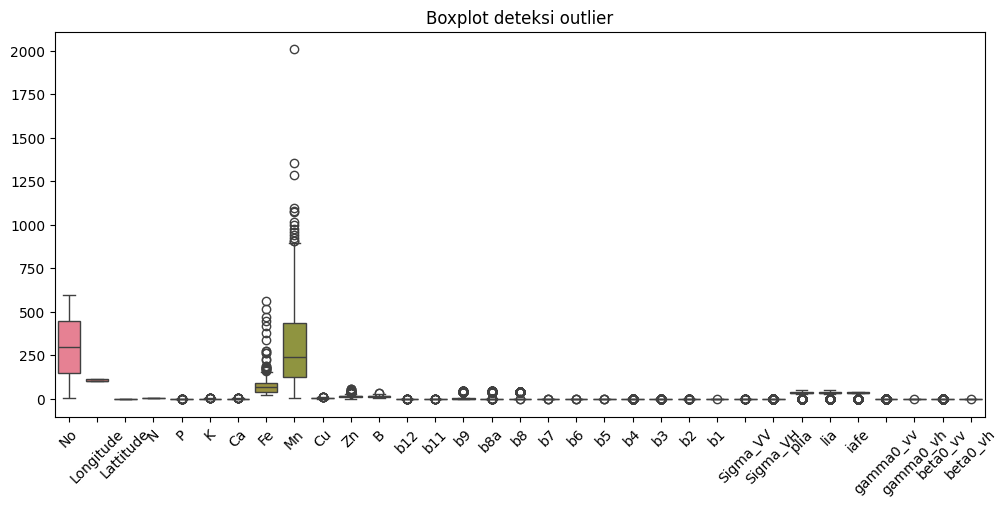

In [19]:
# Cek outlier (boxplot)
plt.figure(figsize=(12,5))
sns.boxplot(data=data.select_dtypes(include=[np.number]))
plt.xticks(rotation=45)
plt.title("Boxplot deteksi outlier")
plt.show()

### **Pilih Target (y) dan Cek Ketersediaan Kolom**
Ubah `target_y` ke `'N'`.


In [20]:
# Pilih target
target_y = "N"

# Tampilkan konfirmasi
print(f"Target yang dipilih: {target_y}")

# Pastikan kolom target ada
if target_y not in df.columns:
    raise ValueError(f"Target '{target_y}' tidak ada di dataset. Kolom tersedia: {df.columns.tolist()}")

Target yang dipilih: N


### **Analisis Korelasi & Pilih Fitur**
##### Tujuan: hitung korelasi Pearson antara target_y dan semua fitur, lalu pilih top-k fitur yang paling berkaitan (nilai absolut korelasi tertinggi).

In [30]:
# Hitung matriks korelasi numerik
corr = data.corr()

# Siapkan daftar kolom yang harus dikecualikan dari fitur:
# - kolom target itu sendiri (target_y)
# - kolom target lain agar tidak dipilih sebagai fitur
targets_all = [c for c in ['N','P','K'] if c in data.columns]
exclude_cols = [t for t in targets_all if t == target_y]

candidate_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c not in targets_all]

# Hitung korelasi antara target_y dan setiap candidate feature
# .loc hanya mengambil korelasi terhadap target yang ada
corr_with_target = corr.loc[candidate_cols, target_y].sort_values(key=lambda x: x.abs(), ascending=False)

# Tampilkan top-10 korelasi untuk inspeksi
display(corr_with_target.head(10))

# Pilih top-1 fitur
top_k = 1
selected_features = corr_with_target.head(top_k).index.tolist()

# Cetak ringkasan fitur terpilih
print(f"Fitur yang dipilih (top-{top_k}): {selected_features}")
print(f"Nilai korelasi terhadap {target_y}: {corr_with_target[selected_features].values[0]:.4f}")

,N
Lattitude,0.742794
Longitude,-0.695291
iafe,-0.593590
lia,-0.593177
plia,-0.592965
gamma0_vh,-0.540866
b9,0.535288
b8a,0.528105
b8,0.526838
beta0_vh,-0.520638


Fitur yang dipilih (top-1): ['Lattitude']
Nilai korelasi terhadap N: 0.7428


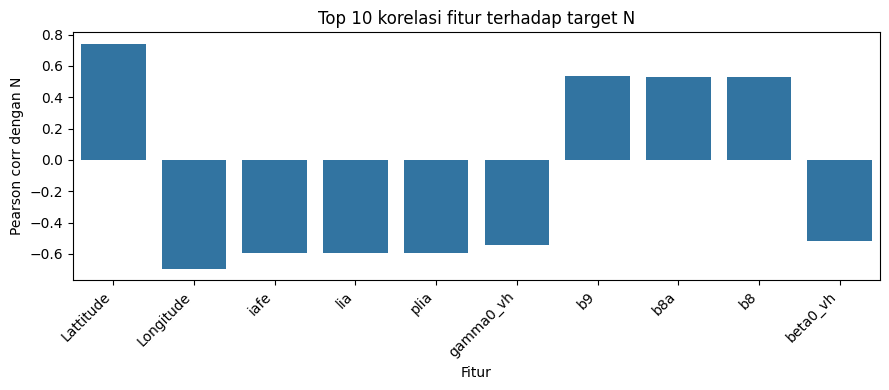

In [31]:
# Visualisasi matrix korelasi dengan plot bar korelasi
topn = 10
top_for_plot = corr_with_target.head(topn)
plt.figure(figsize=(9,4))
sns.barplot(x=top_for_plot.index.astype(str), y=top_for_plot.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel(f'Pearson corr dengan {target_y}')
plt.xlabel('Fitur')
plt.title(f'Top {topn} korelasi fitur terhadap target {target_y}')
plt.tight_layout()
plt.show()

#### **Split Data Train & Test**

In [38]:
from sklearn.model_selection import train_test_split

# Buat X dan y berdasarkan hasil pemilihan fitur
X = data[selected_features]
y = data[target_y]

# Split data menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Data berhasil di-split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Data berhasil di-split:
X_train: (475, 1)
X_test : (119, 1)
y_train: (475,)
y_test : (119,)


#### **Train Model (Linear Regression)**

In [39]:
# Pastikan X_train, y_train sudah ada (hasil split)
from sklearn.linear_model import LinearRegression

# Inisialisasi dan latih model
lr = LinearRegression()        # model regresi linear
lr.fit(X_train, y_train)       # latih pada data training

# Ambil parameter model
intercept = lr.intercept_
coeffs = lr.coef_

# Tampilkan persamaan regresi ringkas
if X_train.shape[1] == 1:
    feat = X_train.columns[0]
    print(f"Persamaan regresi: {target_y} = {intercept:.4f} + ({coeffs[0]:.4f} * {feat})")
else:
    # jika multiple fitur, tampilkan tabel koefisien
    coeff_series = pd.Series(coeffs, index=X_train.columns)
    print("Intercept:", intercept)
    print("Koefisien tiap fitur:")
    display(coeff_series)


Persamaan regresi: N = 2.5654 + (0.3051 * Lattitude)


#### **Evaluasi Model**

In [40]:
# Evaluasi model (MAE, MSE, RMSE, R2)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prediksi pada train dan test
y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

# Hitung metrik
metrics = {
    "train_mae": mean_absolute_error(y_train, y_pred_train),
    "train_mse": mean_squared_error(y_train, y_pred_train),
    "train_rmse": np.sqrt(mean_squared_error(y_train, y_pred_train)),
    "train_r2": r2_score(y_train, y_pred_train),
    "test_mae": mean_absolute_error(y_test, y_pred_test),
    "test_mse": mean_squared_error(y_test, y_pred_test),
    "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    "test_r2": r2_score(y_test, y_pred_test)
}

# Cetak ringkasan metrik
print("=== Evaluasi Model ===")
print(f"Train MAE : {metrics['train_mae']:.4f}")
print(f"Train RMSE: {metrics['train_rmse']:.4f}")
print(f"Train R2  : {metrics['train_r2']:.4f}")
print("-----")
print(f"Test  MAE : {metrics['test_mae']:.4f}")
print(f"Test  RMSE: {metrics['test_rmse']:.4f}")
print(f"Test  R2  : {metrics['test_r2']:.4f}")

=== Evaluasi Model ===
Train MAE : 0.2064
Train RMSE: 0.2628
Train R2  : 0.5583
-----
Test  MAE : 0.2182
Test  RMSE: 0.2719
Test  R2  : 0.5120


#### **Visualisasi: Actual vs Predicted & Residual Plot**

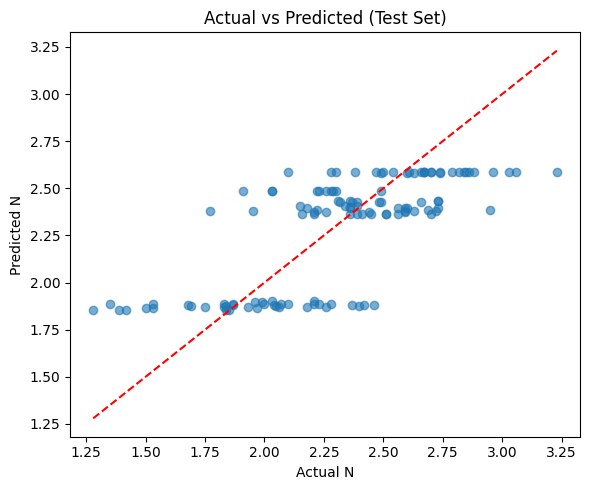

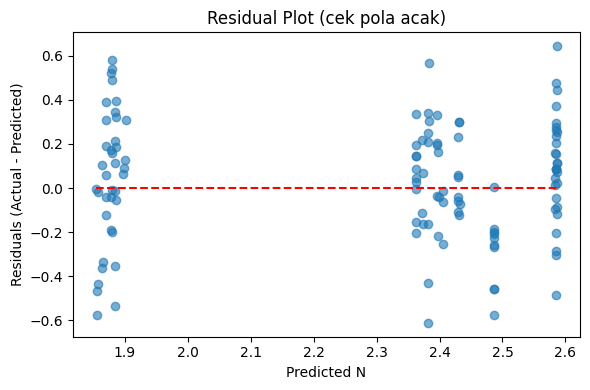

,feature,actual,predicted,residual
30,-0.595580,2.69,2.3837,0.3063
299,-2.228240,2.28,1.8855,0.3945
177,-0.444499,2.48,2.4298,0.0502
204,-0.445417,2.66,2.4295,0.2305
354,-2.249060,2.46,1.8792,0.5808
265,-2.182360,1.99,1.8995,0.0905
464,0.065683,2.10,2.5855,-0.4855
551,0.067328,2.66,2.5860,0.0740
55,-0.257348,2.49,2.4869,0.0031
196,-0.438980,2.31,2.4315,-0.1215


In [41]:
# Visualisasi hasil (Actual vs Predicted) & Residual plot
import matplotlib.pyplot as plt
import numpy as np

# Scatter Actual vs Predicted (Test set)
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # garis y=x
plt.xlabel("Actual " + target_y)
plt.ylabel("Predicted " + target_y)
plt.title("Actual vs Predicted (Test Set)")
plt.tight_layout()
plt.show()

# Residual plot (Predicted vs Residual)
residuals = y_test - y_pred_test
plt.figure(figsize=(6,4))
plt.scatter(y_pred_test, residuals, alpha=0.6)
plt.hlines(0, xmin=y_pred_test.min(), xmax=y_pred_test.max(), colors='r', linestyles='--')
plt.xlabel("Predicted " + target_y)
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (cek pola acak)")
plt.tight_layout()
plt.show()

# Tampilkan beberapa baris perbandingan actual/predicted
comp = pd.DataFrame({
    "feature": X_test.iloc[:,0].values if X_test.shape[1]==1 else X_test.values.tolist(),
    "actual": y_test.values,
    "predicted": np.round(y_pred_test,4),
    "residual": np.round(residuals,4)
}, index=y_test.index)
display(comp.head(15))

#### **OLS: Laporan Statistik**

In [42]:
# OLS summary
import statsmodels.api as sm

# Tambah konstanta (intercept) pada X_train
X_train_sm = sm.add_constant(X_train)
ols_res = sm.OLS(y_train, X_train_sm).fit()

# Tampilkan ringkasan OLS
print(ols_res.summary())

                            OLS Regression Results                            
Dep. Variable:                      N   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     597.8
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.89e-86
Time:                        04:37:19   Log-Likelihood:                -39.248
No. Observations:                 475   AIC:                             82.50
Df Residuals:                     473   BIC:                             90.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5654      0.018    143.945      0.0

#### **Uji Asumsi: Normalitas Residual (QQ-plot + Shapiro)**

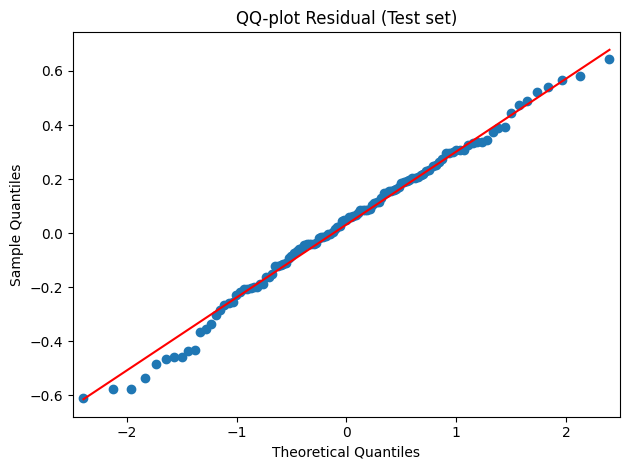

Shapiro-Wilk: stat=0.9893, p=0.4766
→ Residual tampak normal (gagal tolak H0).


In [43]:
# Uji normalitas residual
import scipy.stats as stats
import statsmodels.api as sm

# Gunakan residual dari test set (atau train set)
resid = residuals.dropna()

# QQ-plot
sm.qqplot(resid, line='s')
plt.title("QQ-plot Residual (Test set)")
plt.tight_layout()
plt.show()

# Shapiro-Wilk test
stat, pval = stats.shapiro(resid)
print(f"Shapiro-Wilk: stat={stat:.4f}, p={pval:.4f}")
if pval > 0.05:
    print("→ Residual tampak normal (gagal tolak H0).")
else:
    print("→ Residual tidak normal (tolak H0). Pertimbangkan transformasi.")

#### **Uji Homoskedastisitas (Breusch-Pagan) & Durbin-Watson**

In [44]:
# Uji heteroskedastisitas (Breusch-Pagan) & autokorelasi (Durbin-Watson)
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Persiapkan X_test dengan konstanta
X_test_sm = sm.add_constant(X_test)

# Breusch-Pagan: input (residuals, X)
bp_test = het_breuschpagan(residuals, X_test_sm)
bp_stat, bp_pvalue = bp_test[0], bp_test[1]
print(f"Breusch-Pagan stat={bp_stat:.4f}, p-value={bp_pvalue:.4f}")
if bp_pvalue > 0.05:
    print("→ Tidak ada bukti heteroskedastisitas (homoscedastic).")
else:
    print("→ Terdapat heteroskedastisitas. Pertimbangkan robust std errors / transformasi.")

# Durbin-Watson: cek autokorelasi residual
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.4f}  (nilai ~2 => tidak ada autokorelasi)")

Breusch-Pagan stat=2.0268, p-value=0.1546
→ Tidak ada bukti heteroskedastisitas (homoscedastic).
Durbin-Watson: 2.1549  (nilai ~2 => tidak ada autokorelasi)


#### **Cross-Validation (k-fold) untuk kestabilan performa**

In [45]:
# Cross-Validation (k-fold) — RMSE rata-rata
from sklearn.model_selection import KFold, cross_val_score

# Gunakan X (seluruh data fitur terpilih) dan y
model_cv = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score dengan scoring negative MSE, kemudian ambil sqrt untuk RMSE
neg_mse = cross_val_score(model_cv, X, y, scoring='neg_mean_squared_error', cv=kf)
rmse_scores = np.sqrt(-neg_mse)

print("CV RMSE (5-fold) per fold:", np.round(rmse_scores,4))
print("Mean CV RMSE:", np.round(rmse_scores.mean(),4))
print("Std CV RMSE:", np.round(rmse_scores.std(),4))

CV RMSE (5-fold) per fold: [0.2719 0.273  0.2727 0.257  0.2509]
Mean CV RMSE: 0.2651
Std CV RMSE: 0.0093


#### **Simpan Model**

In [46]:
# Simpan model & ekspor prediksi test ke CSV
import joblib
import os

# Simpan ke drive
save_dir = '/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum07/models/'
os.makedirs(save_dir, exist_ok=True)

# Nama file model
feat_name = X_train.columns[0] if X_train.shape[1]==1 else "multi"
model_path = os.path.join(save_dir, f'linearreg_{target_y}_by_{feat_name}.joblib')

# Simpan model sklearn
joblib.dump(lr, model_path)
print("Model disimpan di:", model_path)

# Simpan metrik ringkas
metrics_summary = {
    "target": target_y,
    "feature": feat_name,
    "train_rmse": metrics['train_rmse'],
    "train_r2": metrics['train_r2'],
    "test_rmse": metrics['test_rmse'],
    "test_r2": metrics['test_r2']
}
metrics_df = pd.DataFrame([metrics_summary])
metrics_file = os.path.join(save_dir, f'metrics_{target_y}_{feat_name}.csv')
metrics_df.to_csv(metrics_file, index=False)
print("Metrik disimpan di:", metrics_file)

# Simpan prediksi test (actual vs predicted)
pred_df = pd.DataFrame({
    "index": y_test.index,
    feat_name: X_test.iloc[:,0] if X_test.shape[1]==1 else list(X_test.values),
    "actual_"+target_y: y_test.values,
    "predicted_"+target_y: np.round(y_pred_test,4),
    "residual": np.round(residuals,4)
})
pred_file = os.path.join(save_dir, f'predictions_{target_y}_{feat_name}.csv')
pred_df.to_csv(pred_file, index=False)
print("Prediksi test disimpan di:", pred_file)

Model disimpan di: /content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum07/models/linearreg_N_by_Lattitude.joblib
Metrik disimpan di: /content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum07/models/metrics_N_Lattitude.csv
Prediksi test disimpan di: /content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum07/models/predictions_N_Lattitude.csv


#### **Evaluasi Model Linear Regression**

In [47]:
# Evaluasi Model Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prediksi pada data training dan testing
y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

# Hitung metrik evaluasi
train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_r2 = r2_score(y_train, y_pred_train)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

# Tampilkan hasil evaluasi
print("=== Evaluasi Model ===")
print(f"Train MAE : {train_mae:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train R²  : {train_r2:.4f}")
print("-----")
print(f"Test  MAE : {test_mae:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"Test  R²  : {test_r2:.4f}")

=== Evaluasi Model ===
Train MAE : 0.2064
Train RMSE: 0.2628
Train R²  : 0.5583
-----
Test  MAE : 0.2182
Test  RMSE: 0.2719
Test  R²  : 0.5120


#### **Verifikasi Model yang sudah disimpan**


In [50]:
# Verify saved model: load & test
import os
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# path model
model_path = '/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum07/models/linearreg_N_by_Lattitude.joblib'

# cek file ada
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file tidak ditemukan: {model_path}")

# load model
loaded_model = joblib.load(model_path)
print("Model berhasil dimuat dari:", model_path)

# bandingkan koef/intercept dengan model asli jika masih di memori
if 'lr' in globals():
    print("Koef model asli    :", getattr(lr, 'coef_', None))
    print("Intercept model asli:", getattr(lr, 'intercept_', None))

print("Koef model loaded  :", getattr(loaded_model, 'coef_', None))
print("Intercept model loaded:", getattr(loaded_model, 'intercept_', None))

# prediksi dengan model yang dimuat pada X_test
if 'X_test' not in globals() or 'y_test' not in globals():
    raise RuntimeError("Variabel X_test/y_test tidak ditemukan. Jalankan ulang cell split data dulu.")

y_pred_loaded = loaded_model.predict(X_test)

# evaluasi
mae_l = mean_absolute_error(y_test, y_pred_loaded)
rmse_l = np.sqrt(mean_squared_error(y_test, y_pred_loaded))
r2_l = r2_score(y_test, y_pred_loaded)

print("\nEvaluasi model yang dimuat (pada X_test):")
print(f"MAE : {mae_l:.4f}")
print(f"RMSE: {rmse_l:.4f}")
print(f"R2  : {r2_l:.4f}")

# hasil prediksi per baris: simpan CSV
pred_df = X_test.copy().reset_index(drop=True)
pred_df['actual_'+str(y_test.name)] = y_test.reset_index(drop=True)
pred_df['predicted_loaded'] = np.round(y_pred_loaded, 4)
pred_save_path = os.path.join(os.path.dirname(model_path), 'predictions_loaded_model.csv')
pred_df.to_csv(pred_save_path, index=False)
print("Prediksi test disimpan ke:", pred_save_path)

Model berhasil dimuat dari: /content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum07/models/linearreg_N_by_Lattitude.joblib
Koef model asli    : [0.30513465]
Intercept model asli: 2.565422308111084
Koef model loaded  : [0.30513465]
Intercept model loaded: 2.565422308111084

Evaluasi model yang dimuat (pada X_test):
MAE : 0.2182
RMSE: 0.2719
R2  : 0.5120
Prediksi test disimpan ke: /content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum07/models/predictions_loaded_model.csv
